### MSCS 634 – Advanced Big Data & Data Mining  
### Lab 4: Regression Techniques + Regularization (Diabetes Dataset)
**Name:** Sagar Bhetwal  
**Date:** February 28, 2026  
**Institution:** University of the Cumberlands  
**Instructor:** Dr. Satish Penmatsa  

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

feature_names = diabetes.feature_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", feature_names)

df.describe()

X shape: (442, 10)
y shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [4]:
df.isna().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

#### Data Cleaning
The Diabetes dataset from scikit-learn is already cleaned and contains no missing values. A missing-value check confirms this.

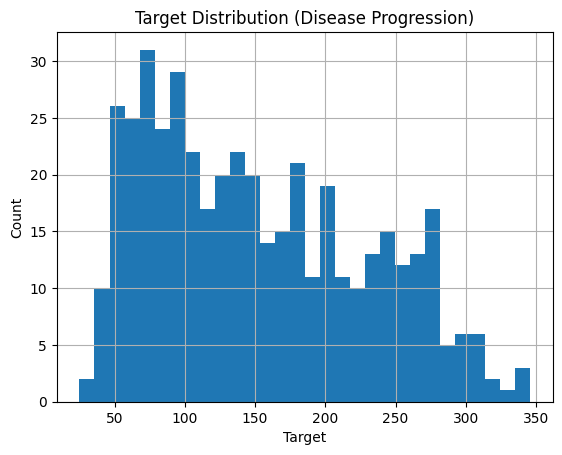

In [5]:
df["target"].hist(bins=30)
plt.title("Target Distribution (Disease Progression)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [6]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()])
    plt.title(title)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

In [7]:
feature = "bmi"
X_simple = df[[feature]].values  # 2D array for sklearn
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

In [8]:
lin_simple = LinearRegression()
lin_simple.fit(X_train, y_train)

y_pred = lin_simple.predict(X_test)

metrics_simple = regression_metrics(y_test, y_pred)
metrics_simple

{'MAE': 52.25997644534553,
 'MSE': 4061.8259284949268,
 'RMSE': np.float64(63.73245584860925),
 'R2': 0.23335039815872138}

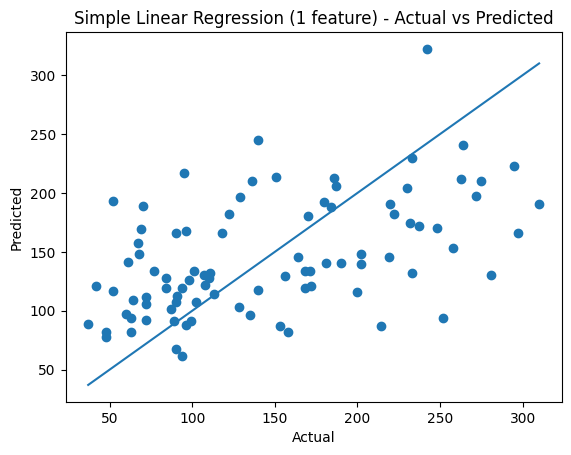

In [9]:
plot_actual_vs_pred(y_test, y_pred, "Simple Linear Regression (1 feature) - Actual vs Predicted")

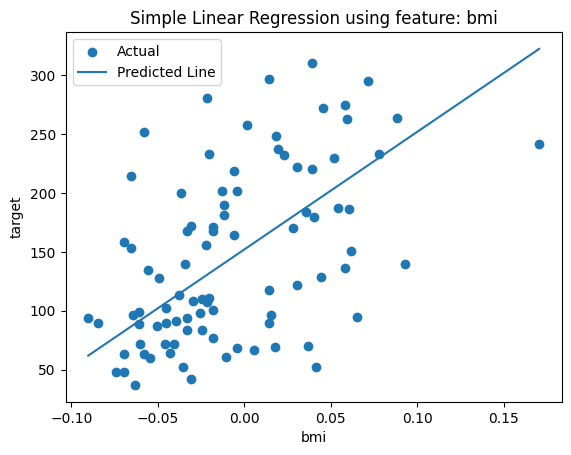

In [10]:
# Sort for nice line plotting
idx = np.argsort(X_test[:, 0])
X_sorted = X_test[idx]
y_sorted = y_test[idx]
y_pred_sorted = y_pred[idx]

plt.figure()
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_sorted, y_pred_sorted, label="Predicted Line")
plt.title(f"Simple Linear Regression using feature: {feature}")
plt.xlabel(feature)
plt.ylabel("target")
plt.legend()
plt.show()

In [11]:
X_all = df[feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

In [12]:
lin_multi = LinearRegression()
lin_multi.fit(X_train, y_train)

y_pred = lin_multi.predict(X_test)

metrics_multi = regression_metrics(y_test, y_pred)
metrics_multi

{'MAE': 42.794094679599944,
 'MSE': 2900.193628493482,
 'RMSE': np.float64(53.85344583676593),
 'R2': 0.45260276297191937}

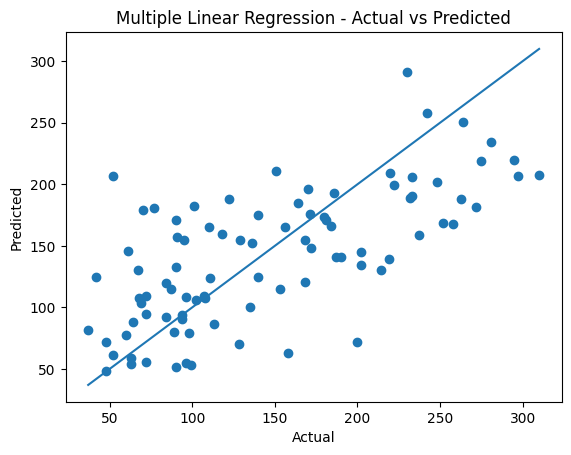

In [13]:
plot_actual_vs_pred(y_test, y_pred, "Multiple Linear Regression - Actual vs Predicted")

In [14]:
X_poly_base = df[[feature]].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_poly_base, y, test_size=0.2, random_state=42
)

degrees = [1, 2, 3, 5, 8]
poly_results = []

for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lin", LinearRegression())
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    m = regression_metrics(y_test, y_pred)
    m["Degree"] = d
    poly_results.append(m)

pd.DataFrame(poly_results).sort_values("Degree")

,MAE,MSE,RMSE,R2,Degree
0,52.259976,4061.825928,63.732456,0.233350,1
1,52.383912,4085.025481,63.914204,0.228972,2
2,52.181400,4064.443384,63.752987,0.232856,3
3,51.884611,4085.845567,63.920619,0.228817,5
4,58.054191,7875.317945,88.742988,-0.486427,8


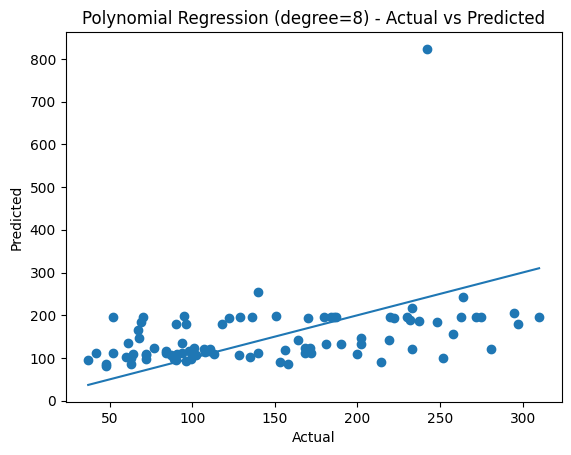

In [15]:
best_degree = 8
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("lin", LinearRegression())
])
poly_model.fit(X_train, y_train)
y_pred = poly_model.predict(X_test)

plot_actual_vs_pred(y_test, y_pred, f"Polynomial Regression (degree={best_degree}) - Actual vs Predicted")

#### Overfitting vs Underfitting (Polynomial Regression)
- Lower degrees (e.g., 1–2) may underfit because they can’t capture curvature.
- Higher degrees can overfit by fitting noise, which may reduce generalization performance on the test set.
- Comparing metrics across degrees helps identify when complexity stops helping.

In [16]:
X_all = df[feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

alphas = [0.01, 0.1, 1, 10, 100]
ridge_results = []
lasso_results = []

for a in alphas:
    ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=a))
    ])
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    m = regression_metrics(y_test, y_pred)
    m["alpha"] = a
    ridge_results.append(m)

    lasso = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=a, max_iter=20000))
    ])
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    m = regression_metrics(y_test, y_pred)
    m["alpha"] = a
    lasso_results.append(m)

ridge_df = pd.DataFrame(ridge_results)
lasso_df = pd.DataFrame(lasso_results)

ridge_df, lasso_df

(         MAE          MSE       RMSE        R2   alpha
 0  42.794171  2900.075130  53.852346  0.452625    0.01
 1  42.796235  2899.054556  53.842869  0.452818    0.10
 2  42.811999  2892.014566  53.777454  0.454147    1.00
 3  42.856825  2875.778718  53.626288  0.457211   10.00
 4  43.250653  2858.224287  53.462363  0.460524  100.00,
          MAE          MSE       RMSE        R2   alpha
 0  42.795018  2898.368019  53.836493  0.452947    0.01
 1  42.805234  2884.624289  53.708698  0.455541    0.10
 2  42.802984  2824.568094  53.146666  0.466877    1.00
 3  44.764599  2933.834730  54.164885  0.446253   10.00
 4  64.006461  5361.533457  73.222493 -0.011963  100.00)

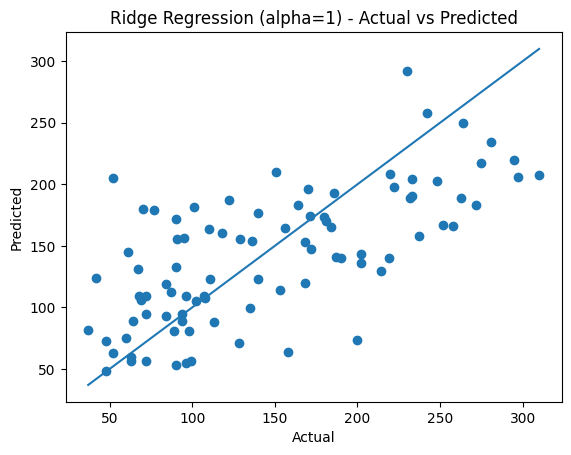

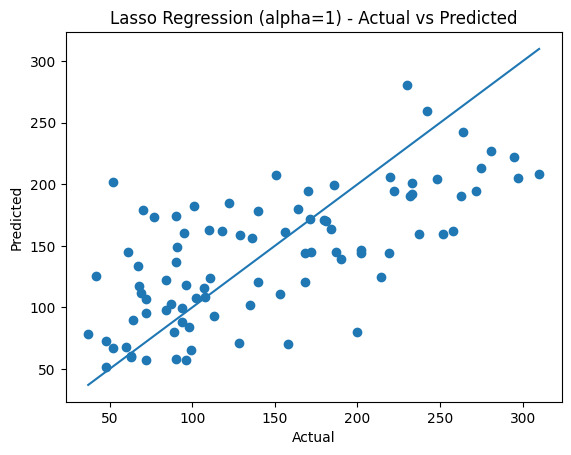

In [17]:
alpha_choice = 1

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=alpha_choice))
])
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=alpha_choice, max_iter=20000))
])
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

plot_actual_vs_pred(y_test, ridge_pred, f"Ridge Regression (alpha={alpha_choice}) - Actual vs Predicted")
plot_actual_vs_pred(y_test, lasso_pred, f"Lasso Regression (alpha={alpha_choice}) - Actual vs Predicted")

In [18]:
lasso_fitted = lasso_model.named_steps["lasso"]
coef = pd.Series(lasso_fitted.coef_, index=feature_names).sort_values(key=np.abs, ascending=False)
coef

bmi    26.219225
s5     22.636465
bp     15.657314
sex    -9.297519
s3     -9.024087
s1     -8.228172
s4      3.420861
s6      2.098647
age     0.687032
s2     -0.000000
dtype: float64

#### Regularization Effects (Ridge vs Lasso)
- **Ridge (L2)** shrinks coefficients smoothly; it usually keeps all features but reduces magnitude.
- **Lasso (L1)** can force some coefficients exactly to zero, effectively performing feature selection.
- **Alpha** controls regularization strength:
  - Small alpha → behaves closer to ordinary linear regression
  - Large alpha → stronger shrinkage (can reduce overfitting but may underfit if too strong)

In [19]:
results = []

# Simple LR (one feature)
results.append({"Model": "Simple Linear Regression (bmi)", **metrics_simple})

# Multiple LR
results.append({"Model": "Multiple Linear Regression (all features)", **metrics_multi})

# Polynomial (choose best degree by R2 from your poly_results table)
poly_df = pd.DataFrame(poly_results)
best_row = poly_df.sort_values("R2", ascending=False).iloc[0]
results.append({
    "Model": f"Polynomial Regression (feature=bmi, degree={int(best_row['Degree'])})",
    "MAE": best_row["MAE"], "MSE": best_row["MSE"], "RMSE": best_row["RMSE"], "R2": best_row["R2"]
})

# Ridge best alpha by R2
best_ridge = ridge_df.sort_values("R2", ascending=False).iloc[0]
results.append({
    "Model": f"Ridge Regression (alpha={best_ridge['alpha']})",
    "MAE": best_ridge["MAE"], "MSE": best_ridge["MSE"], "RMSE": best_ridge["RMSE"], "R2": best_ridge["R2"]
})

# Lasso best alpha by R2
best_lasso = lasso_df.sort_values("R2", ascending=False).iloc[0]
results.append({
    "Model": f"Lasso Regression (alpha={best_lasso['alpha']})",
    "MAE": best_lasso["MAE"], "MSE": best_lasso["MSE"], "RMSE": best_lasso["RMSE"], "R2": best_lasso["R2"]
})

comparison_df = pd.DataFrame(results).sort_values("R2", ascending=False)
comparison_df

,Model,MAE,MSE,RMSE,R2
4,Lasso Regression (alpha=1.0),42.802984,2824.568094,53.146666,0.466877
3,Ridge Regression (alpha=100.0),43.250653,2858.224287,53.462363,0.460524
1,Multiple Linear Regression (all features),42.794095,2900.193628,53.853446,0.452603
0,Simple Linear Regression (bmi),52.259976,4061.825928,63.732456,0.233350
2,"Polynomial Regression (feature=bmi, degree=1)",52.259976,4061.825928,63.732456,0.233350


## Model Comparison & Key Observations

### Performance summary (based on MAE/MSE/RMSE/R²)
- The strongest overall predictive performance came from **Lasso Regression (alpha = 1.0)** with **MAE = 42.80**, **RMSE = 53.15**, and the highest **R² = 0.4669**.
- **Multiple Linear Regression (all features)** was a close second (**MAE = 42.79**, **RMSE = 53.85**, **R² = 0.4526**).
- **Simple Linear Regression (bmi only)** performed noticeably worse (**MAE = 52.26**, **RMSE = 63.73**, **R² = 0.2334**) because it uses only one predictor and cannot capture the combined effect of multiple health factors the dataset provides.

### Overfitting / Underfitting (Polynomial Regression)
- In this run, **Polynomial Regression with degree = 1** produced the *same results* as Simple Linear Regression (bmi only), which is expected because degree 1 polynomial features are equivalent to a straight-line model.
- Since only degree 1 is shown in the final comparison table, overfitting/underfitting across higher polynomial degrees cannot be concluded from this table alone. (In earlier degree testing, higher degrees should be compared to show where performance improves and where it starts degrading due to overfitting.)

### Regularization insights (Ridge vs Lasso)
- **Ridge Regression (alpha = 100.0)** slightly improved generalization compared to ordinary multiple regression (**R² = 0.4605 vs 0.4526**) by shrinking coefficients and reducing model sensitivity to noise.
- **Lasso Regression (alpha = 1.0)** achieved the best overall performance (**R² = 0.4669**) and can drive some coefficients to exactly zero, effectively performing **feature selection**, which improves interpretability.

### Dataset insight
- The Diabetes dataset features are standardized and represent multiple physiological measurements. Results show that models using **multiple features** (Multiple Regression, Ridge, Lasso) predict disease progression much better than using a **single feature** (bmi only), indicating that disease progression is influenced by a combination of factors rather than one measurement alone.

In [20]:
comparison_df.to_csv("model_comparison.csv", index=False)